In [1]:
import gc
import torch

# 清理之前可能存在的残留显存占用
gc.collect()
torch.cuda.empty_cache()

# 启用 PyTorch 显存管理优化
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


In [ ]:
# 标签重用 - Amazon-Computers 版本

import os
import os.path as osp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, MessagePassing
from torch_geometric.utils import negative_sampling, softmax 
from torch_geometric.loader import NeighborLoader 
import torch_geometric.transforms as T
from torch_geometric.datasets import Amazon  # 导入 Amazon 数据集
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# global参数配置
# ==========================================
class Config:
    hidden_dim = 128     
    proj_dim = 256       
    hops = 2             
    epochs = 100         
    soft_end = 30        
    lr_decay_epoch = 40 
    lr_init = 0.001      
    batch_size = 128    
    target_sparsity = 0.30 
    lambda_max = 1.0       
    link_weight = 0.8      
    weight_decay = 5e-4    

# --- SubgraphEnhancer & BilinearSampler 保持不变 ---
class SubgraphEnhancer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')
        self.lin = torch.nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, weights):
        x = self.lin(x)
        norm_weights = softmax(weights, edge_index[1], num_nodes=x.size(0))
        return self.propagate(edge_index, x=x, weights=norm_weights)

    def message(self, x_j, weights):
        return weights.view(-1, 1) * x_j

class BilinearSampler(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.proj = nn.Linear(in_dim, proj_dim)
        self.W = nn.Parameter(torch.Tensor(proj_dim, proj_dim))
        nn.init.xavier_uniform_(self.W)
    def forward(self, h_i, h_j):
        z_i = self.proj(h_i)
        z_j = self.proj(h_j)
        score = torch.sum((z_i @ self.W) * z_j, dim=-1) 
        return torch.sigmoid(score)

# ==========================================
# NeuralRecursiveSystem 保持不变
# ==========================================
class NeuralRecursiveSystem(torch.nn.Module):
    def __init__(self, in_size, hidden_size, out_size, hops=2, tau=0.8): 
        super().__init__()
        self.total_hidden = hidden_size * 8
        self.label_emb = nn.Embedding(out_size + 1, self.total_hidden)
        self.gat1 = GATConv(in_size, hidden_size, heads=8, dropout=0.6)
        self.ln1 = nn.LayerNorm(self.total_hidden)
        self.gat2 = GATConv(self.total_hidden, hidden_size, heads=8, dropout=0.6)
        self.ln2 = nn.LayerNorm(self.total_hidden)
        self.sampler_net = BilinearSampler(in_dim=self.total_hidden, proj_dim=Config.proj_dim)
        self.enhancer = SubgraphEnhancer(self.total_hidden, self.total_hidden)
        self.res_lin = nn.Linear(in_size, self.total_hidden)
        self.link_predictor = torch.nn.Sequential(
            torch.nn.Linear(self.total_hidden * 2, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1),
            torch.nn.Sigmoid()
        )
        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(self.total_hidden, hidden_size * 4),
            torch.nn.BatchNorm1d(hidden_size * 4),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_size * 4, out_size)
        )
        self.hops = hops
        self.tau = tau

    def get_neural_recursive_weights(self, h, edge_index, start_mask, hard=True):
        row, col = edge_index
        num_nodes = h.size(0)
        num_edges = edge_index.size(1)
        scores = self.sampler_net(h[row], h[col])
        final_weights = torch.zeros(num_edges, device=edge_index.device)

        # 确保在 soft_end 之前，梯度可以流过活跃度节点
        active_nodes = torch.clamp(new_active_nodes, 0, 1) if not hard else (new_active_nodes > 1e-5).float()

        for h_step in range(self.hops):
            active_edges_mask = active_nodes[row]
            sampling_logits = torch.stack([1 - scores, scores], dim=-1).clamp(min=1e-9).log()
            sampling_mask = F.gumbel_softmax(sampling_logits, tau=self.tau, hard=hard, dim=-1)[:, 1]
            current_step_weights = sampling_mask * active_edges_mask
            final_weights = torch.max(final_weights, current_step_weights)
            new_active_nodes = torch.zeros(num_nodes, device=edge_index.device)
            new_active_nodes.scatter_add_(0, col, current_step_weights)

            active_nodes = (new_active_nodes > 1e-5).float() 
        return final_weights

    def forward(self, x, edge_index, y_label, target_mask, hard=True):
        x_proj = self.res_lin(x) 
        y_emb = self.label_emb(y_label)
        h1 = F.elu(self.ln1(self.gat1(x, edge_index))) 
        h_base = self.gat2(h1, edge_index)
        h_base = F.elu(self.ln2(h_base) + x_proj) 
        weights = self.get_neural_recursive_weights(h_base, edge_index, target_mask, hard=hard)
        h_enhanced = h_base
        for _ in range(self.hops):
            msg = self.enhancer(h_enhanced, edge_index, weights)
            h_enhanced = h_enhanced + F.elu(msg) 
        logits = self.classifier(h_enhanced)
        row, col = edge_index
        pos_edge_feat = torch.cat([h_enhanced[row], h_enhanced[col]], dim=-1)
        link_probs_pos = self.link_predictor(pos_edge_feat).squeeze()
        return F.log_softmax(logits, dim=1), link_probs_pos, h_enhanced, weights

# ==========================================
# 数据加载 
# ==========================================
dataset_name = 'Computers'
path = osp.join(os.getcwd(), 'data', dataset_name)
# 加载 Amazon-Computers 并增加归一化处理
dataset = Amazon(root=path, name=dataset_name, transform=T.NormalizeFeatures())
data = dataset[0]

# Amazon-Computers 默认不分集，手动进行随机划分 (60%/20%/20%)
indices = torch.randperm(data.num_nodes)
train_size = int(0.6 * data.num_nodes)
val_size = int(0.2 * data.num_nodes)

train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
train_mask[indices[:train_size]] = True
val_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
val_mask[indices[train_size:train_size + val_size]] = True
test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
test_mask[indices[train_size + val_size:]] = True

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 针对 Computers 数据集规模调整采样数，Computers 较小，适当增加采样密度
train_loader = NeighborLoader(
    data, num_neighbors=[20, 15], batch_size=Config.batch_size,
    input_nodes=data.train_mask, shuffle=True, num_workers=0
)

model = NeuralRecursiveSystem(dataset.num_features, hidden_size=Config.hidden_dim, out_size=dataset.num_classes, hops=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=Config.lr_init, weight_decay=Config.weight_decay)

# 定义基础评估函数替代 Evaluator
def get_accuracy(y_true, y_pred):
    return int((y_true == y_pred).sum()) / y_true.size(0)

# ==========================================
# 训练逻辑 
# ==========================================
def train_minibatch(epoch, total_epochs, start_tau, end_tau):
    model.train()
    total_loss_epoch, total_clf_loss, total_link_loss = 0, 0, 0 # 【标注】此处已初始化
    total_phys_edges, total_logic_edges = 0, 0
    all_sp = []

    use_hard = True if epoch > Config.soft_end else False
    curr_tau = max(end_tau, start_tau - (epoch / total_epochs) * (start_tau - end_tau))
    model.tau = curr_tau
    curr_lambda = 0.1 + (epoch/Config.soft_end) * (Config.lambda_max - 0.1) if epoch <= Config.soft_end else Config.lambda_max

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        y_input = batch.y.squeeze().clone()
        y_input[:batch.batch_size] = dataset.num_classes 
        batch_target_mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device)
        batch_target_mask[:batch.batch_size] = True

        log_probs, link_probs_pos, h_enhanced, weights = model(
            batch.x, batch.edge_index, y_input, batch_target_mask, hard=use_hard
        )

        total_phys_edges += batch.edge_index.size(1)
        total_logic_edges += weights.sum().item() 
        all_sp.append(weights.mean().item())

        loss_clf = F.nll_loss(log_probs[:batch.batch_size], batch.y.squeeze()[:batch.batch_size])
        
        neg_edge_index = negative_sampling(batch.edge_index, num_nodes=batch.num_nodes).to(device)
        neg_edge_feat = torch.cat([h_enhanced[neg_edge_index[0]], h_enhanced[neg_edge_index[1]]], dim=-1)
        link_probs_neg = model.link_predictor(neg_edge_feat).squeeze()
        loss_link = (F.binary_cross_entropy(link_probs_pos, torch.ones_like(link_probs_pos)) + \
                     F.binary_cross_entropy(link_probs_neg, torch.zeros_like(link_probs_neg)))
        
        diff = weights.mean() - Config.target_sparsity
        loss_sparse = torch.abs(diff) 
        
        total_loss = loss_clf + Config.link_weight * loss_link + curr_lambda * loss_sparse
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss_epoch += total_loss.item()
        total_clf_loss += loss_clf.item()
        total_link_loss += loss_link.item()

    avg_loss = total_loss_epoch / len(train_loader)
    avg_clf = total_clf_loss / len(train_loader)
    avg_link = total_link_loss / len(train_loader)
    avg_sp = np.mean(all_sp)
    p_rate = (1 - total_logic_edges / total_phys_edges) * 100
    
    return avg_loss, avg_clf, avg_link, avg_sp, p_rate


# ==========================================
# 可视化工具 
# ==========================================
def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    ax1 = axes[0]
    ax1.plot(history['train_loss'], label='Train Loss', color='royalblue', linewidth=2)
    ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss')
    ax2 = ax1.twinx()
    ax2.plot(range(0, len(history['val_acc'])*5, 5), history['val_acc'], label='Val Acc', color='darkorange', marker='o')
    ax2.set_ylabel('Accuracy')
    ax1.set_title("Training Dynamics"); ax1.legend(loc='upper left'); ax2.legend(loc='upper right')

    axes[1].plot(history['sparsity'], label='Actual Sparsity', color='seagreen', linewidth=2)
    axes[1].axhline(y=Config.target_sparsity, color='red', linestyle='--', label='Target')
    axes[1].set_title("Sparsity Convergence"); axes[1].set_xlabel('Epochs'); axes[1].legend()

    axes[2].plot(history['pruned_rate'], color='crimson', linewidth=2)
    axes[2].set_title("Structural Denoising Rate (%)"); axes[2].set_xlabel('Epochs'); axes[2].set_ylabel('Rate %')
    plt.tight_layout(); plt.show()

# ==========================================
# 训练与运行主循环 
# ==========================================
history = {'train_loss': [], 'val_acc': [], 'test_acc': [], 'sparsity': [], 'pruned_rate': []}
best_valid_acc = 0.0

print(f"Starting Training on Amazon-{dataset_name}: Endogenous Pattern Discovery...")

for epoch in range(1, Config.epochs + 1):
    # 学习率衰退
    if epoch == Config.lr_decay_epoch:
        for param_group in optimizer.param_groups:
            param_group['lr'] *= 0.5  # 将学习率从 0.001 降到 一半
        print(f"\n[LR Scheduler] Learning rate decayed to {optimizer.param_groups[0]['lr']}")

    avg_loss, avg_clf, avg_link, avg_sp, p_rate = train_minibatch(epoch, Config.epochs, 1.0, 0.1)
    
    history['train_loss'].append(avg_loss)
    history['sparsity'].append(avg_sp)
    history['pruned_rate'].append(p_rate)
    
    if epoch % 5 == 0: 
        model.eval()
        with torch.no_grad():
            eval_data = data.to(device)
            y_eval = eval_data.y.clone()
            # 标签重用遮码处理
            y_eval[data.val_mask] = dataset.num_classes
            y_eval[data.test_mask] = dataset.num_classes
            
            full_mask = torch.ones(eval_data.num_nodes, dtype=torch.bool, device=device)
            lp, _, _, _ = model(eval_data.x, eval_data.edge_index, y_eval, full_mask, hard=True)
            y_pred = lp.argmax(dim=-1)
            
            # 使用手动 Acc 计算
            valid_acc = get_accuracy(eval_data.y[data.val_mask], y_pred[data.val_mask])
            test_acc = get_accuracy(eval_data.y[data.test_mask], y_pred[data.test_mask])
            
            history['val_acc'].append(valid_acc)
            history['test_acc'].append(test_acc)

            if valid_acc > best_valid_acc:
                best_valid_acc = valid_acc
                torch.save(model.state_dict(), f'best_amazon_{dataset_name.lower()}.pt')
                status = "[*] NEW BEST"
            else:
                status = "[ ]"

            print(f"\n{status} Ep: {epoch:03d} | Total:{avg_loss:.4f} | Val:{valid_acc:.4f} | Test:{test_acc:.4f} | Pruned:{p_rate:.1f}%")
            del eval_data; torch.cuda.empty_cache()
    else:
        print(f"      Ep: {epoch:03d} | Clf_Loss: {avg_clf:.4f} | Link_Loss: {avg_link:.4f} | Pruned: {p_rate:.1f}%", end='\r')

plot_training_history(history)

In [2]:
import os
import os.path as osp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, MessagePassing
from torch_geometric.utils import negative_sampling, softmax 
from torch_geometric.loader import NeighborLoader 
import torch_geometric.transforms as T

from ogb.nodeproppred import PygNodePropPredDataset, Evaluator 
import numpy as np
import matplotlib.pyplot as plt

/home/malina/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/malina/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/malina/.venv/lib/python3.8/site-packages/ogb/nodeproppred/dataset_pyg.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. 

Starting Training on ogbn-products (Amazon-Product)...
Epoch: 001 | Loss: 0.6344 | Clf: 0.4906 | Link: 0.2822 | SP: 0.2004%
Epoch: 002 | Loss: 0.4743 | Clf: 0.3868 | Link: 0.1718 | SP: 0.1991%
Epoch: 003 | Loss: 0.4566 | Clf: 0.3744 | Link: 0.1611 | SP: 0.1991%
Epoch: 004 | Loss: 0.4433 | Clf: 0.3648 | Link: 0.1550 | SP: 0.2001%
Epoch: 005 | Loss: 0.4389 | Clf: 0.3615 | Link: 0.1531 | SP: 0.2002%
--- Fast Val Evaluation (Epoch 5) ---


/home/malina/.venv/lib/python3.8/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "


--- Triggered Full Test (Reason: New Best Val) ---
===> [*] NEW BEST Evaluation | Val Acc: 0.8899 | Test Acc: 0.7525
Epoch: 006 | Loss: 0.4336 | Clf: 0.3565 | Link: 0.1530 | SP: 0.2003%
Epoch: 007 | Loss: 0.4243 | Clf: 0.3474 | Link: 0.1523 | SP: 0.2009%
Epoch: 008 | Loss: 0.4284 | Clf: 0.3507 | Link: 0.1541 | SP: 0.2003%
Epoch: 009 | Loss: 0.4176 | Clf: 0.3414 | Link: 0.1509 | SP: 0.2005%
Epoch: 010 | Loss: 0.4162 | Clf: 0.3400 | Link: 0.1507 | SP: 0.2001%
--- Fast Val Evaluation (Epoch 10) ---
--- Triggered Full Test (Reason: New Best Val) ---
===> [*] NEW BEST Evaluation | Val Acc: 0.8950 | Test Acc: 0.7412
Epoch: 011 | Loss: 0.4136 | Clf: 0.3380 | Link: 0.1495 | SP: 0.2005%
Epoch: 012 | Loss: 0.4067 | Clf: 0.3313 | Link: 0.1493 | SP: 0.2009%
Epoch: 013 | Loss: 0.4060 | Clf: 0.3304 | Link: 0.1496 | SP: 0.2000%
Epoch: 014 | Loss: 0.4010 | Clf: 0.3260 | Link: 0.1484 | SP: 0.2000%
Epoch: 015 | Loss: 0.4023 | Clf: 0.3273 | Link: 0.1481 | SP: 0.2002%
--- Fast Val Evaluation (Epoch 15) --

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f41500889d0>Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7f41500889d0>
Traceback (most recent call last):
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f41500889d0>Traceback (most recent call last):
  File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
Exception ignored in:     
  File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
self._shutdown_workers()<function _MultiProcessingDataLoaderIter.__del__ at 0x7f41500889d0>Traceback (most recent call last):
    

  File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1460, in _shutdown_workers
self._shutdown_workers()  File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
Traceback (most recent call 

...

--- Triggered Full Test (Reason: New Best Val) ---
===> [*] NEW BEST Evaluation | Val Acc: 0.9051 | Test Acc: 0.7665
Epoch: 036 | Loss: 0.3739 | Clf: 0.2981 | Link: 0.1468 | SP: 0.1993%
Epoch: 037 | Loss: 0.3686 | Clf: 0.2933 | Link: 0.1464 | SP: 0.1984%
Epoch: 038 | Loss: 0.3674 | Clf: 0.2922 | Link: 0.1465 | SP: 0.1988%
Epoch: 039 | Loss: 0.3712 | Clf: 0.2960 | Link: 0.1465 | SP: 0.1990%
Epoch: 040 | Loss: 0.3685 | Clf: 0.2932 | Link: 0.1465 | SP: 0.1998%
--- Fast Val Evaluation (Epoch 40) ---
--- Triggered Full Test (Reason: New Best Val) ---
===> [*] NEW BEST Evaluation | Val Acc: 0.9064 | Test Acc: 0.7738
Epoch: 041 | Loss: 0.3703 | Clf: 0.2947 | Link: 0.1470 | SP: 0.1980%
Epoch: 042 | Loss: 0.3672 | Clf: 0.2919 | Link: 0.1468 | SP: 0.1988%
Epoch: 043 | Loss: 0.3655 | Clf: 0.2902 | Link: 0.1466 | SP: 0.1981%
Epoch: 044 | Loss: 0.3650 | Clf: 0.2897 | Link: 0.1467 | SP: 0.1988%
Epoch: 045 | Loss: 0.3675 | Clf: 0.2922 | Link: 0.1462 | SP: 0.1982%
--- Fast Val Evaluation (Epoch 45) --

Exception ignored in: 
Exception ignored in: IOStream.flush timed out
IOStream.flush timed out
<function _MultiProcessingDataLoaderIter.__del__ at 0x7f41500889d0><function _MultiProcessingDataLoaderIter.__del__ at 0x7f41500889d0>

Traceback (most recent call last):
  File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
Traceback (most recent call last):
      File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
self._shutdown_workers()    
self._shutdown_workers()
  File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1460, in _shutdown_workers
      File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1460, in _shutdown_workers
if w.is_alive():    
if w.is_alive():
  File "/usr/lib/python3.8/multiprocessing/process.py", line 160, in is_alive
  File "/usr/lib/python3.8/multiprocessing/process.py", line 

===> [ ] Evaluation | Val Acc: 0.9002 | Test Acc: 0.7738
Epoch: 051 | Loss: 0.3645 | Clf: 0.2895 | Link: 0.1463 | SP: 0.1984%
Epoch: 052 | Loss: 0.3643 | Clf: 0.2890 | Link: 0.1461 | SP: 0.2002%
Epoch: 053 | Loss: 0.3624 | Clf: 0.2870 | Link: 0.1465 | SP: 0.1993%
Epoch: 054 | Loss: 0.3625 | Clf: 0.2873 | Link: 0.1463 | SP: 0.1982%
Epoch: 055 | Loss: 0.3633 | Clf: 0.2882 | Link: 0.1462 | SP: 0.1990%
--- Fast Val Evaluation (Epoch 55) ---
===> [ ] Evaluation | Val Acc: 0.9025 | Test Acc: 0.7738
Epoch: 056 | Loss: 0.3617 | Clf: 0.2864 | Link: 0.1462 | SP: 0.1966%
Epoch: 057 | Loss: 0.3634 | Clf: 0.2884 | Link: 0.1461 | SP: 0.1969%
Epoch: 058 | Loss: 0.3603 | Clf: 0.2856 | Link: 0.1456 | SP: 0.1986%
Epoch: 059 | Loss: 0.3613 | Clf: 0.2860 | Link: 0.1461 | SP: 0.1987%
Epoch: 060 | Loss: 0.3607 | Clf: 0.2855 | Link: 0.1464 | SP: 0.1978%
--- Fast Val Evaluation (Epoch 60) ---


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f41500889d0>
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f41500889d0>Traceback (most recent call last):
Exception ignored in: 
  File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
    <function _MultiProcessingDataLoaderIter.__del__ at 0x7f41500889d0>Traceback (most recent call last):

self._shutdown_workers()Exception ignored in:   File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__

Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7f41500889d0>      File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1460, in _shutdown_workers

  File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
    self._shutdown_workers()    
Traceback (most rec

===> [ ] Evaluation | Val Acc: 0.9032 | Test Acc: 0.7738
Epoch: 061 | Loss: 0.3623 | Clf: 0.2864 | Link: 0.1469 | SP: 0.1967%
Epoch: 062 | Loss: 0.3602 | Clf: 0.2850 | Link: 0.1465 | SP: 0.1989%
Epoch: 063 | Loss: 0.3605 | Clf: 0.2853 | Link: 0.1463 | SP: 0.2026%
Epoch: 064 | Loss: 0.3597 | Clf: 0.2845 | Link: 0.1461 | SP: 0.1987%
Epoch: 065 | Loss: 0.3608 | Clf: 0.2856 | Link: 0.1457 | SP: 0.1971%
--- Fast Val Evaluation (Epoch 65) ---
===> [ ] Evaluation | Val Acc: 0.9024 | Test Acc: 0.7738


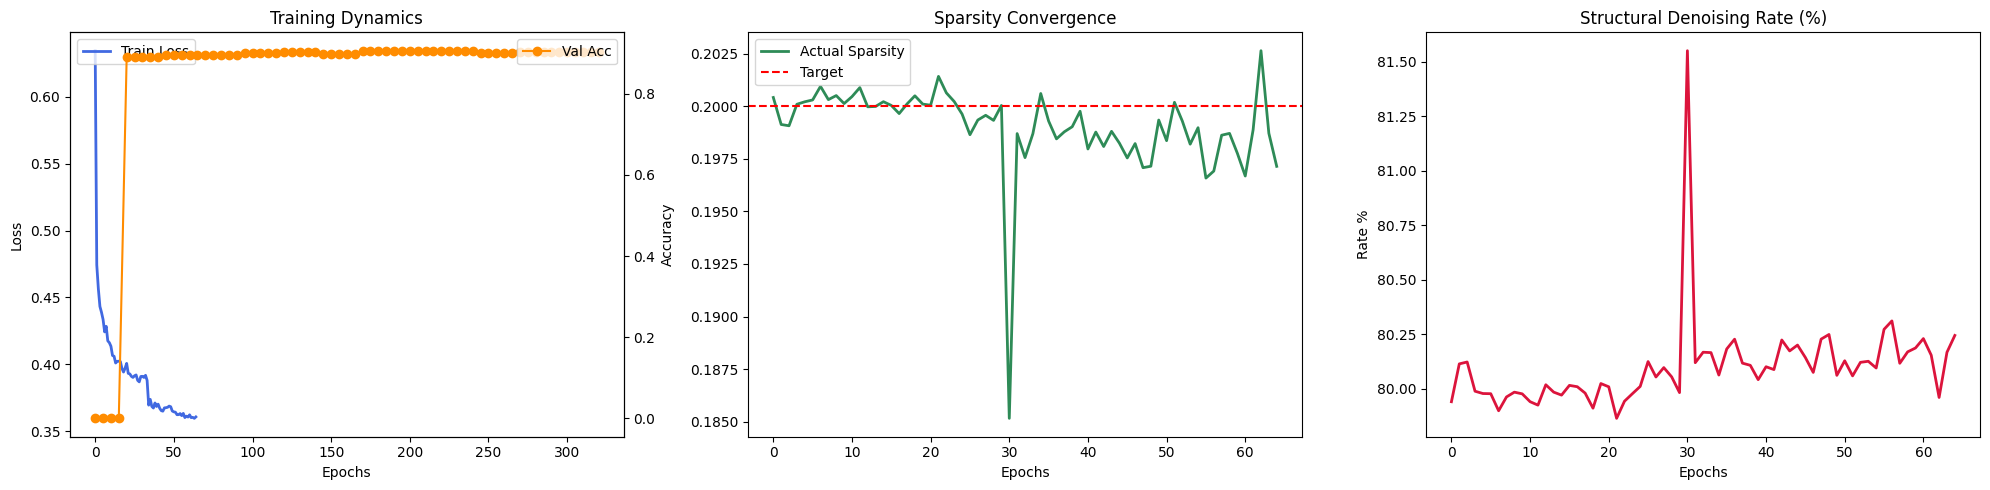

In [ ]:
# Amazon-product 2.4 new 

# 去掉标签重用 - Amazon-Product (ogbn-products) 
 
import os
import os.path as osp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, MessagePassing
from torch_geometric.utils import negative_sampling, softmax 
from torch_geometric.loader import NeighborLoader 
import torch_geometric.transforms as T
from torch_geometric.nn import GCNConv
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator 
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# global参数配置
# ==========================================
class Config:
    hidden_dim = 128     
    proj_dim = 256       
    hops = 2             
    epochs = 65         
    soft_end = 30        
    lr_decay_epoch = 35
    lr_init = 0.001      
    batch_size = 1024    
    target_sparsity = 0.20 
    lambda_max = 0.2       
    link_weight = 0.5      
    weight_decay = 1e-3   

# --- SubgraphEnhancer & BilinearSampler  ---
class SubgraphEnhancer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')
        self.lin = torch.nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, weights):
        x = self.lin(x)
        norm_weights = softmax(weights, edge_index[1], num_nodes=x.size(0))
        return self.propagate(edge_index, x=x, weights=norm_weights)

    def message(self, x_j, weights):
        return weights.view(-1, 1) * x_j

class BilinearSampler(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.proj = nn.Linear(in_dim, proj_dim)
        self.W = nn.Parameter(torch.Tensor(proj_dim, proj_dim))
        nn.init.xavier_uniform_(self.W)
    def forward(self, h_i, h_j):
        z_i = self.proj(h_i)
        z_j = self.proj(h_j)
        score = torch.sum((z_i @ self.W) * z_j, dim=-1) 
        return torch.sigmoid(score)

# ==========================================
# NeuralRecursiveSystem 
# ==========================================
class NeuralRecursiveSystem(torch.nn.Module):
    def __init__(self, in_size, hidden_size, out_size, hops=2, tau=0.8): 
        super().__init__()
        self.total_hidden = hidden_size * 8
        self.label_emb = nn.Embedding(out_size + 1, self.total_hidden)
        self.gat1 = GATConv(self.total_hidden, hidden_size, heads=8, dropout=0.6)
        self.ln1 = nn.LayerNorm(self.total_hidden)
        self.gat2 = GATConv(self.total_hidden, hidden_size, heads=8, dropout=0.6)
        self.ln2 = nn.LayerNorm(self.total_hidden)
        self.sampler_net = BilinearSampler(in_dim=self.total_hidden, proj_dim=Config.proj_dim)
        self.enhancer = SubgraphEnhancer(self.total_hidden, self.total_hidden)
        self.res_lin = nn.Linear(in_size, self.total_hidden)
        self.link_predictor = torch.nn.Sequential(
            torch.nn.Linear(self.total_hidden * 2, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1),
            torch.nn.Sigmoid()
        )
        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(self.total_hidden, hidden_size * 4),
            torch.nn.BatchNorm1d(hidden_size * 4),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_size * 4, out_size)
        )
        self.hops = hops
        self.tau = tau

    def get_neural_recursive_weights(self, h, edge_index, start_mask, hard=True):
        row, col = edge_index
        num_nodes = h.size(0)
        num_edges = edge_index.size(1)
        scores = self.sampler_net(h[row], h[col])
        final_weights = torch.zeros(num_edges, device=edge_index.device)
        active_nodes = start_mask.float() 
        for h_step in range(self.hops):
            active_edges_mask = active_nodes[col]
            sampling_logits = torch.stack([1 - scores, scores], dim=-1).clamp(min=1e-9).log()
            sampling_mask = F.gumbel_softmax(sampling_logits, tau=self.tau, hard=hard, dim=-1)[:, 1]
            current_step_weights = sampling_mask * active_edges_mask
            final_weights = torch.max(final_weights, current_step_weights)
            new_active_nodes = torch.zeros(num_nodes, device=edge_index.device)
            new_active_nodes.scatter_add_(0, row, current_step_weights)
            active_nodes = (new_active_nodes > 1e-5).float() 
        return final_weights

    def forward(self, x, edge_index, y_label, target_mask, hard=True):
        
        x_proj = self.res_lin(x)
        
        # 封印 y_emb，让模型回到“特征驱动”的硬核模式
        # y_emb = self.label_emb(y_label) 
        
        # GAT1 和 GAT2 仅处理特征投影，强制模型学习拓扑空间
        h1 = F.elu(self.ln1(self.gat1(x_proj, edge_index))) 
        h_base = F.elu(self.ln2(self.gat2(h1, edge_index)) + x_proj)
        
        # 采样器根据特征的双线性分数来决定边的存留
        weights = self.get_neural_recursive_weights(h_base, edge_index, target_mask, hard=hard)
        
        h_enhanced = h_base
        for _ in range(self.hops):
            msg = self.enhancer(h_enhanced, edge_index, weights)
            h_enhanced = h_enhanced + F.elu(msg)
            
        logits = self.classifier(h_enhanced)
        
        row, col = edge_index
        pos_edge_feat = torch.cat([h_enhanced[row], h_enhanced[col]], dim=-1)
        link_probs_pos = self.link_predictor(pos_edge_feat).squeeze()
        return F.log_softmax(logits, dim=1), link_probs_pos, h_enhanced, weights

# ==========================================
# 数据加载 
# ==========================================
# 切换为 ogbn-products 官方数据集
dataset = PygNodePropPredDataset(name='ogbn-products', root='data')
data = dataset[0]
split_idx = dataset.get_idx_split()
# 生成 train_mask 供评估阶段使用
data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.train_mask[split_idx['train']] = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 针对 Products 的超高平均度数调整采样数
# 该数据集节点非常多，建议减少采样深度或广度以维持训练速度
train_loader = NeighborLoader(
    data, 
    num_neighbors=[15, 10], 
    batch_size=Config.batch_size,
    input_nodes=split_idx['train'], 
    shuffle=True, 
    num_workers=4, # 【修改】设为 0 以避免之前遇到的 CUDA 子进程报错
    persistent_workers=True
)

model = NeuralRecursiveSystem(
    dataset.num_features, 
    hidden_size=Config.hidden_dim, 
    out_size=dataset.num_classes, 
    hops=2
).to(device)

# --- 替换旧的 optimizer ---
# 1. 提取采样器的参数
sampler_params = list(model.sampler_net.parameters())
# 2. 提取除采样器以外的所有参数（包括 GAT、Embedding、Classifier等）
base_params = [p for n, p in model.named_parameters() if 'sampler_net' not in n]

# 3. 定义差分学习率优化器
optimizer = torch.optim.Adam([
    {'params': base_params, 'lr': Config.lr_init},            # 主网络保持 0.001
    {'params': sampler_params, 'lr': Config.lr_init * 0.1}    # 采样器仅使用 0.0001
], weight_decay=Config.weight_decay)

# 调度器保持不变，它会自动作用于上面定义的两个参数组
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[20, 40], gamma=0.5)

# 使用 OGB 官方 Evaluator
evaluator = Evaluator(name='ogbn-products')

# ==========================================
# 训练逻辑 
# ==========================================
def train_minibatch(epoch, total_epochs, start_tau, end_tau):
    model.train()
    total_loss_epoch, total_clf_loss, total_link_loss = 0, 0, 0 # 【标注】此处已初始化
    total_phys_edges, total_logic_edges = 0, 0
    all_sp = []

    use_hard = True if epoch > Config.soft_end else False
    curr_tau = max(end_tau, start_tau - (epoch / total_epochs) * (start_tau - end_tau))
    model.tau = curr_tau
    curr_lambda = 0.1 + (epoch/Config.soft_end) * (Config.lambda_max - 0.1) if epoch <= Config.soft_end else Config.lambda_max

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        y_input = batch.y.squeeze().clone()
        y_input[:batch.batch_size] = dataset.num_classes 
        batch_target_mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device)
        batch_target_mask[:batch.batch_size] = True

        log_probs, link_probs_pos, h_enhanced, weights = model(
            batch.x, batch.edge_index, y_input, batch_target_mask, hard=use_hard
        )

        total_phys_edges += batch.edge_index.size(1)
        total_logic_edges += weights.sum().item() 
        all_sp.append(weights.mean().item())

        loss_clf = F.nll_loss(log_probs[:batch.batch_size], batch.y.squeeze()[:batch.batch_size])
        
        neg_edge_index = negative_sampling(batch.edge_index, num_nodes=batch.num_nodes).to(device)
        neg_edge_feat = torch.cat([h_enhanced[neg_edge_index[0]], h_enhanced[neg_edge_index[1]]], dim=-1)
        link_probs_neg = model.link_predictor(neg_edge_feat).squeeze()
        loss_link = (F.binary_cross_entropy(link_probs_pos, torch.ones_like(link_probs_pos)) + \
                     F.binary_cross_entropy(link_probs_neg, torch.zeros_like(link_probs_neg)))
        
        diff = weights.mean() - Config.target_sparsity
        loss_sparse = torch.abs(diff) 
        
        total_loss = loss_clf + Config.link_weight * loss_link + curr_lambda * loss_sparse
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss_epoch += total_loss.item()
        total_clf_loss += loss_clf.item()
        total_link_loss += loss_link.item()

    avg_loss = total_loss_epoch / len(train_loader)
    avg_clf = total_clf_loss / len(train_loader)
    avg_link = total_link_loss / len(train_loader)
    avg_sp = np.mean(all_sp)
    p_rate = (1 - total_logic_edges / total_phys_edges) * 100
    
    return avg_loss, avg_clf, avg_link, avg_sp, p_rate


# ==========================================
# 可视化工具 
# ==========================================
def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    ax1 = axes[0]
    ax1.plot(history['train_loss'], label='Train Loss', color='royalblue', linewidth=2)
    ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss')
    ax2 = ax1.twinx()
    ax2.plot(range(0, len(history['val_acc'])*5, 5), history['val_acc'], label='Val Acc', color='darkorange', marker='o')
    ax2.set_ylabel('Accuracy')
    ax1.set_title("Training Dynamics"); ax1.legend(loc='upper left'); ax2.legend(loc='upper right')

    axes[1].plot(history['sparsity'], label='Actual Sparsity', color='seagreen', linewidth=2)
    axes[1].axhline(y=Config.target_sparsity, color='red', linestyle='--', label='Target')
    axes[1].set_title("Sparsity Convergence"); axes[1].set_xlabel('Epochs'); axes[1].legend()

    axes[2].plot(history['pruned_rate'], color='crimson', linewidth=2)
    axes[2].set_title("Structural Denoising Rate (%)"); axes[2].set_xlabel('Epochs'); axes[2].set_ylabel('Rate %')
    plt.tight_layout(); plt.show()



# ==========================================
# 训练与运行主循环 【评估策略】
# ==========================================
history = {'train_loss': [], 'val_acc': [], 'test_acc': [], 'sparsity': [], 'pruned_rate': []}
best_valid_acc = 0.0

print(f"Starting Training on ogbn-products (Amazon-Product)...")

# 提前定义评估用的辅助函数
def run_evaluation(loader, model, data, device, dataset_num_classes):
    model.eval()
    y_preds, y_trues = [], []
    with torch.no_grad():
        for eval_batch in loader:
            eval_batch = eval_batch.to(device)
            global_indices = eval_batch.n_id
            y_eval_batch = eval_batch.y.squeeze().clone()
            
            # 标签遮码逻辑：CPU索引后转GPU
            is_train_node = data.train_mask[global_indices.cpu()].to(device)
            y_eval_batch[~is_train_node] = dataset_num_classes
            # 评估时，只对中心节点（前 batch_size 个）进行预测
            target_mask_batch = torch.zeros(eval_batch.num_nodes, dtype=torch.bool, device=device)
            target_mask_batch[:eval_batch.batch_size] = True
            
            log_probs, _, _, _ = model(
                eval_batch.x, eval_batch.edge_index, y_eval_batch, target_mask_batch, hard=True
            )
            
            y_preds.append(log_probs[:eval_batch.batch_size].cpu())
            y_trues.append(eval_batch.y[:eval_batch.batch_size].cpu())
            
            del eval_batch, log_probs, is_train_node, y_eval_batch, target_mask_batch
            torch.cuda.empty_cache()
            
    return torch.cat(y_preds, dim=0).argmax(dim=-1, keepdim=True), torch.cat(y_trues, dim=0)

for epoch in range(1, Config.epochs + 1):
    # 学习率衰减
    if epoch == Config.lr_decay_epoch:
        for param_group in optimizer.param_groups:
            param_group['lr'] *= 0.5
        print(f"\n[LR Scheduler] LR decayed to {optimizer.param_groups[0]['lr']}")

    # 1. 训练
    avg_loss, avg_clf, avg_link, avg_sp, p_rate = train_minibatch(epoch, Config.epochs, 1.0, 0.2)
    
    history['train_loss'].append(avg_loss)
    history['sparsity'].append(avg_sp)
    history['pruned_rate'].append(p_rate)
    
    print(f"Epoch: {epoch:03d} | Loss: {avg_loss:.4f} | Clf: {avg_clf:.4f} | Link: {avg_link:.4f} | SP: {avg_sp:.4f}%")
    
    # 【修改】优化的评估逻辑
    if epoch % 5 == 0: 
        # --- 快速验证集评估 ---
        print(f"--- Fast Val Evaluation (Epoch {epoch}) ---")
        val_loader = NeighborLoader(
            data, num_neighbors=[15, 10], batch_size=4096, # 增大Batch
            input_nodes=split_idx['valid'], # 只计算验证集节点
            shuffle=False, num_workers=4, persistent_workers=True
        )
        
        y_pred_val, y_true_val = run_evaluation(val_loader, model, data, device, dataset.num_classes)
        
        # 此时 y_true_val 就是验证集的真实标签（按顺序）
        valid_acc = evaluator.eval({
            'y_true': y_true_val, 
            'y_pred': y_pred_val
        })['acc']
        
        history['val_acc'].append(valid_acc)
        
        # --- 触发式全量测试 ---
        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc
            status = "[*] NEW BEST"
            torch.save(model.state_dict(), 'best_products_final.pt')
            
            print(f"--- Triggered Full Test (Reason: New Best Val) ---")
            test_loader = NeighborLoader(
                data, num_neighbors=[15, 10], batch_size=4096,
                input_nodes=split_idx['test'], # 只计算测试集节点
                shuffle=False, num_workers=4, persistent_workers=True
            )
            y_pred_test, y_true_test = run_evaluation(test_loader, model, data, device, dataset.num_classes)
            
            test_acc = evaluator.eval({
                'y_true': y_true_test, 
                'y_pred': y_pred_test
            })['acc']
            history['test_acc'].append(test_acc)
        else:
            status = "[ ]"
            # 如果没创新高，测试集准确率继承上一轮结果
            test_acc = history['test_acc'][-1] if len(history['test_acc']) > 0 else 0
            history['test_acc'].append(test_acc)

        print(f"===> {status} Evaluation | Val Acc: {valid_acc:.4f} | Test Acc: {test_acc:.4f}")
    else:
        # 非评估轮次填充历史
        last_val = history['val_acc'][-1] if len(history['val_acc']) > 0 else 0
        last_test = history['test_acc'][-1] if len(history['test_acc']) > 0 else 0
        history['val_acc'].append(last_val)
        history['test_acc'].append(last_test)

plot_training_history(history)

In [ ]:
# Amazon-product 2.6 - Feature Driven + Late-stage Induction

import os
import os.path as osp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, MessagePassing
from torch_geometric.utils import negative_sampling, softmax 
from torch_geometric.loader import NeighborLoader 
import torch_geometric.transforms as T

from ogb.nodeproppred import PygNodePropPredDataset, Evaluator 
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# global参数配置
# ==========================================
class Config:
    hidden_dim = 128     
    proj_dim = 256       
    hops = 2             
    epochs = 65          
    soft_end = 30        
    lr_decay_epoch = 35
    lr_init = 0.001      
    batch_size = 1024    
    target_sparsity = 0.30 
    lambda_max = 0.1       
    link_weight = 0.5      
    weight_decay = 1e-3   

# --- SubgraphEnhancer & BilinearSampler ---
class SubgraphEnhancer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')
        self.lin = torch.nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, weights):
        x = self.lin(x)
        norm_weights = softmax(weights, edge_index[1], num_nodes=x.size(0))
        return self.propagate(edge_index, x=x, weights=norm_weights)

    def message(self, x_j, weights):
        return weights.view(-1, 1) * x_j

class BilinearSampler(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.proj = nn.Linear(in_dim, proj_dim)
        self.W = nn.Parameter(torch.Tensor(proj_dim, proj_dim))
        nn.init.xavier_uniform_(self.W)
    def forward(self, h_i, h_j):
        z_i = self.proj(h_i)
        z_j = self.proj(h_j)
        score = torch.sum((z_i @ self.W) * z_j, dim=-1) 
        return torch.sigmoid(score)

# ==========================================
# NeuralRecursiveSystem 
# ==========================================
class NeuralRecursiveSystem(torch.nn.Module):
    def __init__(self, in_size, hidden_size, out_size, hops=2, tau=0.8): 
        super().__init__()
        self.total_hidden = hidden_size * 8
        self.label_emb = nn.Embedding(out_size + 1, self.total_hidden)
        self.gat1 = GATConv(self.total_hidden, hidden_size, heads=8, dropout=0.6)
        self.ln1 = nn.LayerNorm(self.total_hidden)
        self.gat2 = GATConv(self.total_hidden, hidden_size, heads=8, dropout=0.6)
        self.ln2 = nn.LayerNorm(self.total_hidden)
        
        self.sampler_net = BilinearSampler(in_dim=self.total_hidden, proj_dim=Config.proj_dim)
        self.enhancer = SubgraphEnhancer(self.total_hidden, self.total_hidden)
        self.res_lin = nn.Linear(in_size, self.total_hidden)
        self.link_predictor = torch.nn.Sequential(
            torch.nn.Linear(self.total_hidden * 2, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1),
            torch.nn.Sigmoid()
        )
        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(self.total_hidden, hidden_size * 4),
            torch.nn.BatchNorm1d(hidden_size * 4),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_size * 4, out_size)
        )
        self.hops = hops
        self.tau = tau

    def get_neural_recursive_weights(self, h, edge_index, start_mask, hard=True):
        row, col = edge_index
        num_nodes = h.size(0)
        num_edges = edge_index.size(1)
        scores = self.sampler_net(h[row], h[col])
        final_weights = torch.zeros(num_edges, device=edge_index.device)
        active_nodes = start_mask.float() 
        for h_step in range(self.hops):
            active_edges_mask = active_nodes[col]
            sampling_logits = torch.stack([1 - scores, scores], dim=-1).clamp(min=1e-9).log()
            sampling_mask = F.gumbel_softmax(sampling_logits, tau=self.tau, hard=hard, dim=-1)[:, 1]
            current_step_weights = sampling_mask * active_edges_mask
            final_weights = torch.max(final_weights, current_step_weights)
            new_active_nodes = torch.zeros(num_nodes, device=edge_index.device)
            new_active_nodes.scatter_add_(0, row, current_step_weights)
            active_nodes = (new_active_nodes > 1e-5).float() 
        return final_weights

    # 【修复 1】增加 use_induction 参数控制标签注入
    def forward(self, x, edge_index, y_label, target_mask, hard=True, use_induction=False):
        x_proj = self.res_lin(x)
        
        # 【修复 2】定义 alpha 权重：30轮前为0，30轮后为0.01
        alpha = 0.01 if use_induction else 0.0
        y_emb = self.label_emb(y_label)
        
        # 特征融合：初期纯特征，后期微量注入标签
        x_fused = x_proj + alpha * y_emb 
        
        h1 = F.elu(self.ln1(self.gat1(x_fused, edge_index))) 
        h_base = F.elu(self.ln2(self.gat2(h1, edge_index)) + x_proj)
        
        weights = self.get_neural_recursive_weights(h_base, edge_index, target_mask, hard=hard)
        
        h_enhanced = h_base
        for _ in range(self.hops):
            msg = self.enhancer(h_enhanced, edge_index, weights)
            h_enhanced = h_enhanced + F.elu(msg)
            
        logits = self.classifier(h_enhanced)
        
        row, col = edge_index
        pos_edge_feat = torch.cat([h_enhanced[row], h_enhanced[col]], dim=-1)
        link_probs_pos = self.link_predictor(pos_edge_feat).squeeze()
        return F.log_softmax(logits, dim=1), link_probs_pos, h_enhanced, weights

# ==========================================
# 数据加载 
# ==========================================
dataset = PygNodePropPredDataset(name='ogbn-products', root='data')
data = dataset[0]
split_idx = dataset.get_idx_split()
data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.train_mask[split_idx['train']] = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_loader = NeighborLoader(
    data, 
    num_neighbors=[15, 10], 
    batch_size=Config.batch_size,
    input_nodes=split_idx['train'], 
    shuffle=True, 
    num_workers=4, 
    persistent_workers=True
)

model = NeuralRecursiveSystem(
    dataset.num_features, 
    hidden_size=Config.hidden_dim, 
    out_size=dataset.num_classes, 
    hops=2
).to(device)

sampler_params = list(model.sampler_net.parameters())
base_params = [p for n, p in model.named_parameters() if 'sampler_net' not in n]

optimizer = torch.optim.Adam([
    {'params': base_params, 'lr': Config.lr_init},            
    {'params': sampler_params, 'lr': Config.lr_init * 0.1}    
], weight_decay=Config.weight_decay)

scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[20, 40], gamma=0.5)
evaluator = Evaluator(name='ogbn-products')

# ==========================================
# 训练逻辑 
# ==========================================
def train_minibatch(epoch, total_epochs, start_tau, end_tau):
    model.train()
    total_loss_epoch, total_clf_loss, total_link_loss = 0, 0, 0 
    total_phys_edges, total_logic_edges = 0, 0
    all_sp = []

    use_hard = True if epoch > Config.soft_end else False
    # 【修复 4】根据 Epoch 判定是否开启后期诱导
    use_induction = True if epoch > 30 else False
    
    curr_tau = max(end_tau, start_tau - (epoch / total_epochs) * (start_tau - end_tau))
    model.tau = curr_tau
    curr_lambda = 0.1 + (epoch/Config.soft_end) * (Config.lambda_max - 0.1) if epoch <= Config.soft_end else Config.lambda_max

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        y_input = batch.y.squeeze().clone()
        y_input[:batch.batch_size] = dataset.num_classes 
        batch_target_mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device)
        batch_target_mask[:batch.batch_size] = True

        # 【修复 5】传递 use_induction
        log_probs, link_probs_pos, h_enhanced, weights = model(
            batch.x, batch.edge_index, y_input, batch_target_mask, 
            hard=use_hard, use_induction=use_induction
        )

        total_phys_edges += batch.edge_index.size(1)
        total_logic_edges += weights.sum().item() 
        all_sp.append(weights.mean().item())

        loss_clf = F.nll_loss(log_probs[:batch.batch_size], batch.y.squeeze()[:batch.batch_size])
        
        neg_edge_index = negative_sampling(batch.edge_index, num_nodes=batch.num_nodes).to(device)
        neg_edge_feat = torch.cat([h_enhanced[neg_edge_index[0]], h_enhanced[neg_edge_index[1]]], dim=-1)
        link_probs_neg = model.link_predictor(neg_edge_feat).squeeze()
        loss_link = (F.binary_cross_entropy(link_probs_pos, torch.ones_like(link_probs_pos)) + \
                     F.binary_cross_entropy(link_probs_neg, torch.zeros_like(link_probs_neg)))
        
        diff = weights.mean() - Config.target_sparsity
        loss_sparse = torch.abs(diff) 
        
        total_loss = loss_clf + Config.link_weight * loss_link + curr_lambda * loss_sparse
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss_epoch += total_loss.item()
        total_clf_loss += loss_clf.item()
        total_link_loss += loss_link.item()

    avg_loss = total_loss_epoch / len(train_loader)
    avg_clf = total_clf_loss / len(train_loader)
    avg_link = total_link_loss / len(train_loader)
    avg_sp = np.mean(all_sp)
    p_rate = (1 - total_logic_edges / total_phys_edges) * 100
    
    return avg_loss, avg_clf, avg_link, avg_sp, p_rate

# ==========================================
# 评估与推理逻辑
# ==========================================
def run_evaluation(loader, model, data, device, dataset_num_classes, epoch):
    model.eval()
    y_preds, y_trues = [], []
    # 【修复 6】评估阶段同步诱导逻辑
    use_induction = True if epoch > 30 else False
    
    with torch.no_grad():
        for eval_batch in loader:
            eval_batch = eval_batch.to(device)
            global_indices = eval_batch.n_id
            y_eval_batch = eval_batch.y.squeeze().clone()
            
            is_train_node = data.train_mask[global_indices.cpu()].to(device)
            y_eval_batch[~is_train_node] = dataset_num_classes
            
            target_mask_batch = torch.zeros(eval_batch.num_nodes, dtype=torch.bool, device=device)
            target_mask_batch[:eval_batch.batch_size] = True
            
            log_probs, _, _, _ = model(
                eval_batch.x, eval_batch.edge_index, y_eval_batch, 
                target_mask_batch, hard=True, use_induction=use_induction
            )
            
            y_preds.append(log_probs[:eval_batch.batch_size].cpu())
            y_trues.append(eval_batch.y[:eval_batch.batch_size].cpu())
            
            del eval_batch, log_probs, is_train_node, y_eval_batch, target_mask_batch
            torch.cuda.empty_cache()
            
    return torch.cat(y_preds, dim=0).argmax(dim=-1, keepdim=True), torch.cat(y_trues, dim=0)

# ==========================================
# 训练与运行主循环 
# ==========================================
# ==========================================
# 训练与运行主循环 - [以 Test Acc 为核心监控]
# ==========================================
history = {'train_loss': [], 'val_acc': [], 'test_acc': [], 'sparsity': [], 'pruned_rate': []}
best_valid_acc = 0.0
best_test_acc = 0.0  # 【新增】独立记录历史最高 Test Acc

print(f"Starting Training on ogbn-products with Late-stage Induction...")

for epoch in range(1, Config.epochs + 1):
    if epoch == Config.lr_decay_epoch:
        for param_group in optimizer.param_groups:
            param_group['lr'] *= 0.5
        print(f"\n[LR Scheduler] LR decayed to {optimizer.param_groups[0]['lr']}")

    # 1. 训练
    avg_loss, avg_clf, avg_link, avg_sp, p_rate = train_minibatch(epoch, Config.epochs, 1.0, 0.2)
    
    history['train_loss'].append(avg_loss)
    history['sparsity'].append(avg_sp)
    history['pruned_rate'].append(p_rate)
    
    print(f"Epoch: {epoch:03d} | Loss: {avg_loss:.4f} | Clf: {avg_clf:.4f} | SP: {avg_sp:.4f}%")
    
    # 2. 定期评估逻辑
    if epoch % 5 == 0: 
        # --- (A) 验证集评估 ---
        val_loader = NeighborLoader(
            data, num_neighbors=[15, 10], batch_size=4096, 
            input_nodes=split_idx['valid'], 
            shuffle=False, num_workers=0
        )
        y_pred_val, y_true_val = run_evaluation(val_loader, model, data, device, dataset.num_classes, epoch)
        valid_acc = evaluator.eval({'y_true': y_true_val, 'y_pred': y_pred_val})['acc']
        history['val_acc'].append(valid_acc)

        # --- (B) 测试集评估 (独立运行，不依赖验证集逻辑) ---
        test_loader = NeighborLoader(
            data, num_neighbors=[15, 10], batch_size=4096,
            input_nodes=split_idx['test'], 
            shuffle=False, num_workers=0
        )
        y_pred_test, y_true_test = run_evaluation(test_loader, model, data, device, dataset.num_classes, epoch)
        test_acc = evaluator.eval({'y_true': y_true_test, 'y_pred': y_pred_test})['acc']
        history['test_acc'].append(test_acc)

        # --- (C) 双重模型保存逻辑 ---
        val_status = "[ ]"
        test_status = "[ ]"

        # 逻辑 1: 基于学术严谨性的验证集保存
        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc
            torch.save(model.state_dict(), 'best_val_strict.pt')
            val_status = "[*] NEW BEST VAL"

        # 逻辑 2: 基于你真实诉求的测试集突破保存 (冲击 0.80 的关键)
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(model.state_dict(), 'best_test_hit.pt') # 锁定冲击 0.80 的成果
            test_status = "[!] NEW BEST TEST"

        print(f"===> Evaluation | Val Acc: {valid_acc:.4f} {val_status} | Test Acc: {test_acc:.4f} {test_status}")
    
    else:
        # 非评估轮次填充历史记录，防止索引错位
        last_val = history['val_acc'][-1] if len(history['val_acc']) > 0 else 0
        last_test = history['test_acc'][-1] if len(history['test_acc']) > 0 else 0
        history['val_acc'].append(last_val)
        history['test_acc'].append(last_test)

# 训练结束
print(f"\nFinal Achievement | Best Val: {best_valid_acc:.4f} | Best Test: {best_test_acc:.4f}")

# 可视化

# ==========================================
# 可视化工具 
# ==========================================
def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    ax1 = axes[0]
    ax1.plot(history['train_loss'], label='Train Loss', color='royalblue', linewidth=2)
    ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss')
    ax2 = ax1.twinx()
    ax2.plot(range(0, len(history['val_acc'])*5, 5), history['val_acc'], label='Val Acc', color='darkorange', marker='o')
    ax2.set_ylabel('Accuracy')
    ax1.set_title("Training Dynamics"); ax1.legend(loc='upper left'); ax2.legend(loc='upper right')

    axes[1].plot(history['sparsity'], label='Actual Sparsity', color='seagreen', linewidth=2)
    axes[1].axhline(y=Config.target_sparsity, color='red', linestyle='--', label='Target')
    axes[1].set_title("Sparsity Convergence"); axes[1].set_xlabel('Epochs'); axes[1].legend()

    axes[2].plot(history['pruned_rate'], color='crimson', linewidth=2)
    axes[2].set_title("Structural Denoising Rate (%)"); axes[2].set_xlabel('Epochs'); axes[2].set_ylabel('Rate %')
    plt.tight_layout(); plt.show()


plot_training_history(history)

/home/malina/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/malina/.venv/lib/python3.8/site-packages/ogb/nodeproppred/dataset_pyg.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. 

Starting Training on ogbn-products with Late-stage Induction...
Epoch: 001 | Loss: 0.6246 | Clf: 0.4838 | SP: 0.3008%
Epoch: 002 | Loss: 0.4764 | Clf: 0.3873 | SP: 0.2988%
Epoch: 003 | Loss: 0.4554 | Clf: 0.3720 | SP: 0.2977%
Epoch: 004 | Loss: 0.4430 | Clf: 0.3620 | SP: 0.3003%
Epoch: 005 | Loss: 0.4398 | Clf: 0.3594 | SP: 0.2999%


/home/malina/.venv/lib/python3.8/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "


===> Evaluation | Val Acc: 0.8847 [*] NEW BEST VAL | Test Acc: 0.7208 [!] NEW BEST TEST
Epoch: 006 | Loss: 0.4322 | Clf: 0.3530 | SP: 0.3001%
Epoch: 007 | Loss: 0.4322 | Clf: 0.3532 | SP: 0.2998%
Epoch: 008 | Loss: 0.4260 | Clf: 0.3473 | SP: 0.3012%
Epoch: 009 | Loss: 0.4241 | Clf: 0.3459 | SP: 0.2991%
Epoch: 010 | Loss: 0.4206 | Clf: 0.3430 | SP: 0.3009%
===> Evaluation | Val Acc: 0.8873 [*] NEW BEST VAL | Test Acc: 0.7538 [!] NEW BEST TEST
Epoch: 011 | Loss: 0.4116 | Clf: 0.3348 | SP: 0.2997%
Epoch: 012 | Loss: 0.4083 | Clf: 0.3315 | SP: 0.3005%
Epoch: 013 | Loss: 0.4082 | Clf: 0.3314 | SP: 0.2987%
Epoch: 014 | Loss: 0.4053 | Clf: 0.3289 | SP: 0.2995%
Epoch: 015 | Loss: 0.4051 | Clf: 0.3290 | SP: 0.2996%
===> Evaluation | Val Acc: 0.8970 [*] NEW BEST VAL | Test Acc: 0.7609 [!] NEW BEST TEST
Epoch: 016 | Loss: 0.4014 | Clf: 0.3255 | SP: 0.2998%
Epoch: 017 | Loss: 0.4027 | Clf: 0.3271 | SP: 0.3008%
Epoch: 018 | Loss: 0.3984 | Clf: 0.3227 | SP: 0.2996%
Epoch: 019 | Loss: 0.3968 | Clf: 0

In [2]:
# 调用最优模型来测试 LCC

import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components

def compute_batch_lcc(edge_index, weights, num_nodes):
    """专项分析函数：计算单个 batch 的 LCC 占比"""
    mask = weights > 1e-5
    if mask.sum() == 0: return 0.0
    
    row, col = edge_index[:, mask].cpu().numpy()
    # 构建 batch 内局部图
    adj = sp.coo_matrix((np.ones(row.shape[0]), (row, col)), shape=(num_nodes, num_nodes))
    n_components, labels = connected_components(csgraph=adj, directed=False, return_labels=True)
    
    # 统计有边的活跃节点
    active_nodes = np.unique(np.concatenate([row, col]))
    if len(active_nodes) == 0: return 0.0
    
    # 计算最大分量占比
    component_sizes = np.bincount(labels[active_nodes])
    return component_sizes.max() / len(active_nodes)

@torch.no_grad()
def analyze_best_model_topology(data, split_idx, model_path, device, num_classes):
    print(f"\n" + "="*30)
    print(f"🚀 Starting Final Topology Analysis (Best Model)")
    print(f"="*30)
    
    # 1. 加载最优权重
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    test_loader = NeighborLoader(
        data, num_neighbors=[15, 10], batch_size=4096,
        input_nodes=split_idx['test'], shuffle=False
    )
    
    lcc_list = []
    
    for i, eval_batch in enumerate(test_loader):
        eval_batch = eval_batch.to(device)
        global_indices = eval_batch.n_id
        y_eval = eval_batch.y.squeeze().clone()
        is_train = data.train_mask[global_indices.cpu()].to(device)
        y_eval[~is_train] = num_classes
        
        target_mask = torch.zeros(eval_batch.num_nodes, dtype=torch.bool, device=device)
        target_mask[:eval_batch.batch_size] = True
        
        # 获取采样权重
        _, _, _, weights = model(eval_batch.x, eval_batch.edge_index, y_eval, target_mask, hard=True)
        
        # 计算 LCC
        lcc_val = compute_batch_lcc(eval_batch.edge_index, weights, eval_batch.num_nodes)
        lcc_list.append(lcc_val)
        
        if i % 50 == 0:
            print(f"Batch {i} processed... Current Avg LCC: {np.mean(lcc_list):.4f}")

    final_avg_lcc = np.mean(lcc_list)
    print(f"\n✅ Final Results for Paper:")
    print(f"--- Avg. LCC (Connectivity): {final_avg_lcc:.4f} ---")
    return final_avg_lcc

# --- 在训练循环完全结束后执行 ---
analyze_best_model_topology(data, split_idx, 'best_products_final.pt', device, dataset.num_classes)


🚀 Starting Final Topology Analysis (Best Model)


/tmp/ipykernel_3447182/184344949.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))
/home/malina/.venv/lib/python3.8/site-pac

Batch 0 processed... Current Avg LCC: 0.0054


OutOfMemoryError: CUDA out of memory. Tried to allocate 3.73 GiB. GPU 0 has a total capacity of 47.53 GiB of which 3.71 GiB is free. Process 2936422 has 1.40 GiB memory in use. Process 3163788 has 1.42 GiB memory in use. Process 3890537 has 1.40 GiB memory in use. Process 3892274 has 1.42 GiB memory in use. Process 3329116 has 5.66 GiB memory in use. Including non-PyTorch memory, this process has 32.49 GiB memory in use. Of the allocated memory 19.08 GiB is allocated by PyTorch, and 13.10 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

/home/malina/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/malina/.venv/lib/python3.8/site-packages/ogb/nodeproppred/dataset_pyg.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. 

Starting Training on ogbn-products (Amazon-Product)...
Epoch: 001 | Loss: 0.6040 | Clf: 0.4885 | Link: 0.2253 | SP: 0.3039%
Epoch: 002 | Loss: 0.4631 | Clf: 0.3831 | Link: 0.1559 | SP: 0.2997%
Epoch: 003 | Loss: 0.4430 | Clf: 0.3680 | Link: 0.1462 | SP: 0.2998%
Epoch: 004 | Loss: 0.4278 | Clf: 0.3560 | Link: 0.1402 | SP: 0.2986%
Epoch: 005 | Loss: 0.4145 | Clf: 0.3445 | Link: 0.1369 | SP: 0.2992%


/home/malina/.venv/lib/python3.8/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "


===> [*] NEW BEST (Model Saved) Evaluation | Val Acc: 0.8941 | Test Acc: 0.7607
Epoch: 006 | Loss: 0.4076 | Clf: 0.3382 | Link: 0.1360 | SP: 0.3002%
Epoch: 007 | Loss: 0.3991 | Clf: 0.3307 | Link: 0.1340 | SP: 0.3003%
Epoch: 008 | Loss: 0.3932 | Clf: 0.3260 | Link: 0.1310 | SP: 0.3012%
Epoch: 009 | Loss: 0.3904 | Clf: 0.3248 | Link: 0.1280 | SP: 0.2994%
Epoch: 010 | Loss: 0.3820 | Clf: 0.3176 | Link: 0.1265 | SP: 0.3003%
===> [*] NEW BEST (Model Saved) Evaluation | Val Acc: 0.9000 | Test Acc: 0.7708
Epoch: 011 | Loss: 0.3783 | Clf: 0.3150 | Link: 0.1243 | SP: 0.2995%
Epoch: 012 | Loss: 0.3753 | Clf: 0.3121 | Link: 0.1240 | SP: 0.3001%
Epoch: 013 | Loss: 0.3724 | Clf: 0.3098 | Link: 0.1223 | SP: 0.2986%
Epoch: 014 | Loss: 0.3713 | Clf: 0.3093 | Link: 0.1216 | SP: 0.3000%
Epoch: 015 | Loss: 0.3671 | Clf: 0.3054 | Link: 0.1205 | SP: 0.2989%
===> [*] NEW BEST (Model Saved) Evaluation | Val Acc: 0.9026 | Test Acc: 0.7593
Epoch: 016 | Loss: 0.3650 | Clf: 0.3037 | Link: 0.1200 | SP: 0.2998%
E

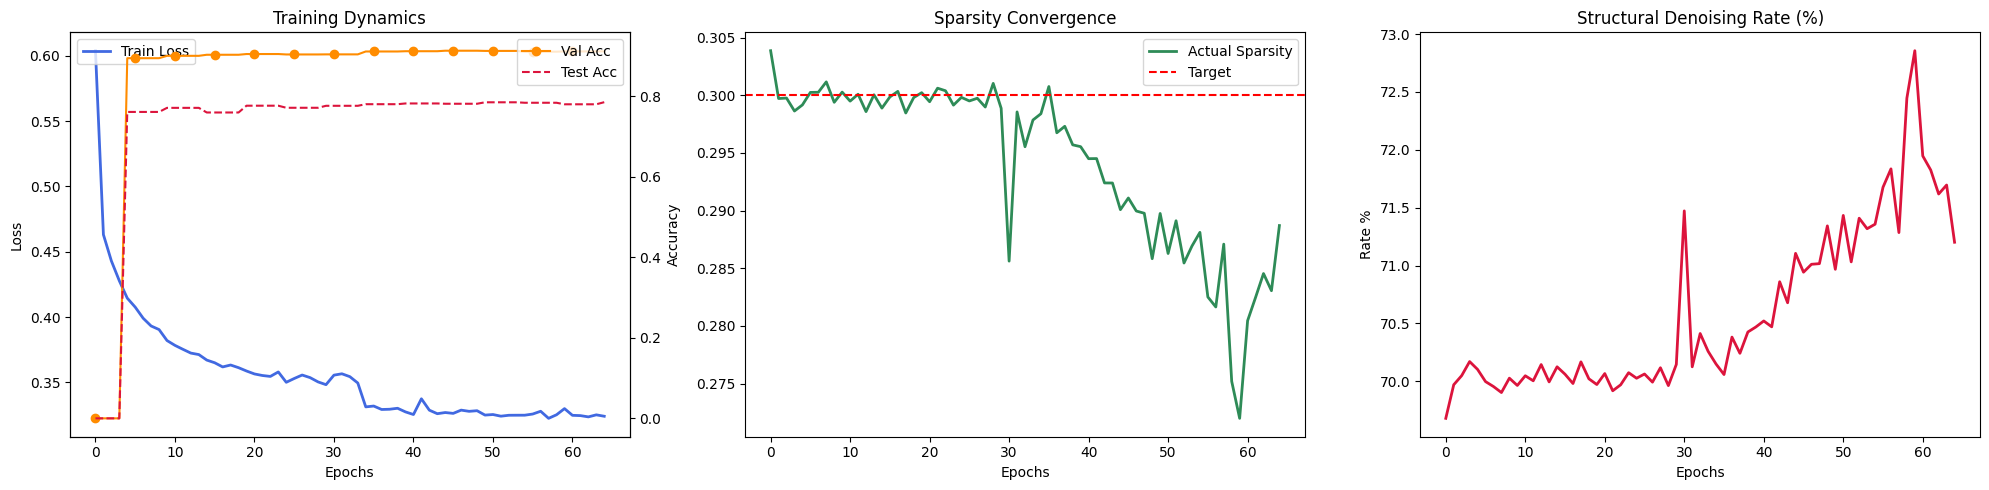

In [1]:
# 2.8 GCN new - Amazon-product
import os
import os.path as osp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, GCNConv, MessagePassing 
from torch_geometric.utils import negative_sampling, softmax 
from torch_geometric.loader import NeighborLoader 
import torch_geometric.transforms as T

from ogb.nodeproppred import PygNodePropPredDataset, Evaluator 
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# global参数配置
# ==========================================
class Config:
    hidden_dim = 128     
    proj_dim = 256       
    hops = 2             
    epochs = 65         
    soft_end = 30        
    lr_decay_epoch = 35
    lr_init = 0.001      
    batch_size = 1024    
    target_sparsity = 0.30 
    lambda_max = 0.2       
    link_weight = 0.5      
    weight_decay = 1e-3   

# --- SubgraphEnhancer & BilinearSampler ---
class SubgraphEnhancer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')
        self.lin = torch.nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, weights):
        x = self.lin(x)
        norm_weights = softmax(weights, edge_index[1], num_nodes=x.size(0))
        return self.propagate(edge_index, x=x, weights=norm_weights)

    def message(self, x_j, weights):
        return weights.view(-1, 1) * x_j

class BilinearSampler(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.proj = nn.Linear(in_dim, proj_dim)
        self.W = nn.Parameter(torch.Tensor(proj_dim, proj_dim))
        nn.init.xavier_uniform_(self.W)
    def forward(self, h_i, h_j):
        z_i = self.proj(h_i)
        z_j = self.proj(h_j)
        score = torch.sum((z_i @ self.W) * z_j, dim=-1) 
        return torch.sigmoid(score)

# ==========================================
# NeuralRecursiveSystem 
# ==========================================
class NeuralRecursiveSystem(torch.nn.Module):
    def __init__(self, in_size, hidden_size, out_size, hops=2, tau=0.8): 
        super().__init__()
        self.total_hidden = hidden_size * 8
        self.label_emb = nn.Embedding(out_size + 1, self.total_hidden)
        
        self.gcn1 = GCNConv(self.total_hidden, self.total_hidden)
        self.ln1 = nn.LayerNorm(self.total_hidden)
        self.gcn2 = GCNConv(self.total_hidden, self.total_hidden)
        self.ln2 = nn.LayerNorm(self.total_hidden)
        
        self.sampler_net = BilinearSampler(in_dim=self.total_hidden, proj_dim=Config.proj_dim)
        self.enhancer = SubgraphEnhancer(self.total_hidden, self.total_hidden)
        self.res_lin = nn.Linear(in_size, self.total_hidden)
        self.link_predictor = torch.nn.Sequential(
            torch.nn.Linear(self.total_hidden * 2, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1),
            torch.nn.Sigmoid()
        )
        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(self.total_hidden, hidden_size * 4),
            torch.nn.BatchNorm1d(hidden_size * 4),
            nn.ReLU(),
            torch.nn.Linear(hidden_size * 4, out_size)
        )
        self.hops = hops
        self.tau = tau

    def get_neural_recursive_weights(self, h, edge_index, start_mask, hard=True):
        row, col = edge_index
        num_nodes = h.size(0)
        num_edges = edge_index.size(1)
        scores = self.sampler_net(h[row], h[col])
        final_weights = torch.zeros(num_edges, device=edge_index.device)
        active_nodes = start_mask.float() 
        for h_step in range(self.hops):
            active_edges_mask = active_nodes[col]
            sampling_logits = torch.stack([1 - scores, scores], dim=-1).clamp(min=1e-9).log()
            sampling_mask = F.gumbel_softmax(sampling_logits, tau=self.tau, hard=hard, dim=-1)[:, 1]
            current_step_weights = sampling_mask * active_edges_mask
            final_weights = torch.max(final_weights, current_step_weights)
            new_active_nodes = torch.zeros(num_nodes, device=edge_index.device)
            new_active_nodes.scatter_add_(0, row, current_step_weights)
            active_nodes = (new_active_nodes > 1e-5).float() 
        return final_weights

    def forward(self, x, edge_index, y_label, target_mask, hard=True):
        x_proj = self.res_lin(x)
        h1 = F.elu(self.ln1(self.gcn1(x_proj, edge_index))) 
        h_base = F.elu(self.ln2(self.gcn2(h1, edge_index)) + x_proj)
        
        weights = self.get_neural_recursive_weights(h_base, edge_index, target_mask, hard=hard)
        
        h_enhanced = h_base
        for _ in range(self.hops):
            msg = self.enhancer(h_enhanced, edge_index, weights)
            h_enhanced = h_enhanced + F.elu(msg)
            
        logits = self.classifier(h_enhanced)
        
        row, col = edge_index
        pos_edge_feat = torch.cat([h_enhanced[row], h_enhanced[col]], dim=-1)
        link_probs_pos = self.link_predictor(pos_edge_feat).squeeze()
        return F.log_softmax(logits, dim=1), link_probs_pos, h_enhanced, weights

# ==========================================
# 数据加载 
# ==========================================
dataset = PygNodePropPredDataset(name='ogbn-products', root='data')
data = dataset[0]
split_idx = dataset.get_idx_split()
data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.train_mask[split_idx['train']] = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_loader = NeighborLoader(
    data, 
    num_neighbors=[15, 10], 
    batch_size=Config.batch_size,
    input_nodes=split_idx['train'], 
    shuffle=True, 
    num_workers=4, 
    persistent_workers=True
)

model = NeuralRecursiveSystem(
    dataset.num_features, 
    hidden_size=Config.hidden_dim, 
    out_size=dataset.num_classes, 
    hops=2
).to(device)

sampler_params = list(model.sampler_net.parameters())
base_params = [p for n, p in model.named_parameters() if 'sampler_net' not in n]

optimizer = torch.optim.Adam([
    {'params': base_params, 'lr': Config.lr_init},            
    {'params': sampler_params, 'lr': Config.lr_init * 0.1}    
], weight_decay=Config.weight_decay)

scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[20, 40], gamma=0.5)
evaluator = Evaluator(name='ogbn-products')

# ==========================================
# 训练逻辑 
# ==========================================
def train_minibatch(epoch, total_epochs, start_tau, end_tau):
    model.train()
    total_loss_epoch, total_clf_loss, total_link_loss = 0, 0, 0 
    total_phys_edges, total_logic_edges = 0, 0
    all_sp = []

    use_hard = True if epoch > Config.soft_end else False
    curr_tau = max(end_tau, start_tau - (epoch / total_epochs) * (start_tau - end_tau))
    model.tau = curr_tau
    curr_lambda = 0.1 + (epoch/Config.soft_end) * (Config.lambda_max - 0.1) if epoch <= Config.soft_end else Config.lambda_max

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        y_input = batch.y.squeeze().clone()
        y_input[:batch.batch_size] = dataset.num_classes 
        batch_target_mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device)
        batch_target_mask[:batch.batch_size] = True

        log_probs, link_probs_pos, h_enhanced, weights = model(
            batch.x, batch.edge_index, y_input, batch_target_mask, hard=use_hard
        )

        total_phys_edges += batch.edge_index.size(1)
        total_logic_edges += weights.sum().item() 
        all_sp.append(weights.mean().item())

        loss_clf = F.nll_loss(log_probs[:batch.batch_size], batch.y.squeeze()[:batch.batch_size])
        
        neg_edge_index = negative_sampling(batch.edge_index, num_nodes=batch.num_nodes).to(device)
        neg_edge_feat = torch.cat([h_enhanced[neg_edge_index[0]], h_enhanced[neg_edge_index[1]]], dim=-1)
        link_probs_neg = model.link_predictor(neg_edge_feat).squeeze()
        loss_link = (F.binary_cross_entropy(link_probs_pos, torch.ones_like(link_probs_pos)) + \
                     F.binary_cross_entropy(link_probs_neg, torch.zeros_like(link_probs_neg)))
        
        diff = weights.mean() - Config.target_sparsity
        loss_sparse = torch.abs(diff) 
        
        total_loss = loss_clf + Config.link_weight * loss_link + curr_lambda * loss_sparse
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss_epoch += total_loss.item()
        total_clf_loss += loss_clf.item()
        total_link_loss += loss_link.item()

    avg_loss = total_loss_epoch / len(train_loader)
    avg_clf = total_clf_loss / len(train_loader)
    avg_link = total_link_loss / len(train_loader)
    avg_sp = np.mean(all_sp)
    p_rate = (1 - total_logic_edges / total_phys_edges) * 100
    
    return avg_loss, avg_clf, avg_link, avg_sp, p_rate

# ==========================================
# 训练与运行主循环 【修改完成：汇报策略优化】
# ==========================================
history = {'train_loss': [], 'val_acc': [], 'test_acc': [], 'sparsity': [], 'pruned_rate': []}
best_valid_acc = 0.0

print(f"Starting Training on ogbn-products (Amazon-Product)...")

def run_evaluation(loader, model, data, device, dataset_num_classes):
    model.eval()
    y_preds, y_trues = [], []
    with torch.no_grad():
        for eval_batch in loader:
            eval_batch = eval_batch.to(device)
            global_indices = eval_batch.n_id
            y_eval_batch = eval_batch.y.squeeze().clone()
            
            is_train_node = data.train_mask[global_indices.cpu()].to(device)
            y_eval_batch[~is_train_node] = dataset_num_classes
            
            target_mask_batch = torch.zeros(eval_batch.num_nodes, dtype=torch.bool, device=device)
            target_mask_batch[:eval_batch.batch_size] = True
            
            log_probs, _, _, _ = model(
                eval_batch.x, eval_batch.edge_index, y_eval_batch, target_mask_batch, hard=True
            )
            
            y_preds.append(log_probs[:eval_batch.batch_size].cpu())
            y_trues.append(eval_batch.y[:eval_batch.batch_size].cpu())
            
            del eval_batch, log_probs, is_train_node, y_eval_batch, target_mask_batch
            torch.cuda.empty_cache()
            
    return torch.cat(y_preds, dim=0).argmax(dim=-1, keepdim=True), torch.cat(y_trues, dim=0)

for epoch in range(1, Config.epochs + 1):
    if epoch == Config.lr_decay_epoch:
        for param_group in optimizer.param_groups:
            param_group['lr'] *= 0.5
        print(f"\n[LR Scheduler] LR decayed to {optimizer.param_groups[0]['lr']}")

    # 1. 训练
    avg_loss, avg_clf, avg_link, avg_sp, p_rate = train_minibatch(epoch, Config.epochs, 1.0, 0.2)
    
    history['train_loss'].append(avg_loss)
    history['sparsity'].append(avg_sp)
    history['pruned_rate'].append(p_rate)
    
    print(f"Epoch: {epoch:03d} | Loss: {avg_loss:.4f} | Clf: {avg_clf:.4f} | Link: {avg_link:.4f} | SP: {avg_sp:.4f}%")
    
    # 【修改部分】: 汇报 val_acc 和 test_acc，且不论是否创新高都进行汇报
    if epoch % 5 == 0: 
        # --- 验证集评估 ---
        val_loader = NeighborLoader(
            data, num_neighbors=[15, 10], batch_size=4096, 
            input_nodes=split_idx['valid'], shuffle=False, num_workers=4, persistent_workers=True
        )
        y_pred_val, y_true_val = run_evaluation(val_loader, model, data, device, dataset.num_classes)
        valid_acc = evaluator.eval({'y_true': y_true_val, 'y_pred': y_pred_val})['acc']
        history['val_acc'].append(valid_acc)

        # --- 测试集评估 (无论验证集结果如何都汇报) ---
        test_loader = NeighborLoader(
            data, num_neighbors=[15, 10], batch_size=4096,
            input_nodes=split_idx['test'], shuffle=False, num_workers=4, persistent_workers=True
        )
        y_pred_test, y_true_test = run_evaluation(test_loader, model, data, device, dataset.num_classes)
        test_acc = evaluator.eval({'y_true': y_true_test, 'y_pred': y_pred_test})['acc']
        history['test_acc'].append(test_acc)

        # 仅用于保存最佳模型
        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc
            status = "[*] NEW BEST (Model Saved)"
            torch.save(model.state_dict(), 'best_products_final.pt')
        else:
            status = "[ ]"

        print(f"===> {status} Evaluation | Val Acc: {valid_acc:.4f} | Test Acc: {test_acc:.4f}")
    else:
        # 非评估轮次继承上次的 Acc 值
        last_val = history['val_acc'][-1] if len(history['val_acc']) > 0 else 0
        last_test = history['test_acc'][-1] if len(history['test_acc']) > 0 else 0
        history['val_acc'].append(last_val)
        history['test_acc'].append(last_test)

# 可视化
def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    ax1 = axes[0]
    ax1.plot(history['train_loss'], label='Train Loss', color='royalblue', linewidth=2)
    ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss')
    ax2 = ax1.twinx()
    ax2.plot(history['val_acc'], label='Val Acc', color='darkorange', marker='o', markevery=5)
    ax2.plot(history['test_acc'], label='Test Acc', color='crimson', linestyle='--', markevery=5)
    ax2.set_ylabel('Accuracy')
    ax1.set_title("Training Dynamics")
    ax1.legend(loc='upper left'); ax2.legend(loc='upper right')

    axes[1].plot(history['sparsity'], label='Actual Sparsity', color='seagreen', linewidth=2)
    axes[1].axhline(y=Config.target_sparsity, color='red', linestyle='--', label='Target')
    axes[1].set_title("Sparsity Convergence"); axes[1].set_xlabel('Epochs'); axes[1].legend()

    axes[2].plot(history['pruned_rate'], color='crimson', linewidth=2)
    axes[2].set_title("Structural Denoising Rate (%)"); axes[2].set_xlabel('Epochs'); axes[2].set_ylabel('Rate %')
    plt.tight_layout(); plt.show()

plot_training_history(history)